In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Dropout
)

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.optimizers import Adam

2026-05-18 05:26:13.078731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779081973.421221      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779081973.523418      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779081974.539696      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779081974.539754      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779081974.539757      57 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

X = []
Y = []

IMG_SIZE = 224

base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

# ============================================================
# LOAD IMAGES
# ============================================================

for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

        Y.append(label)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.array(X, dtype='float32')

Y = np.array(Y)

print("Dataset Shape :", X.shape)

# ============================================================
# NORMALIZE
# ============================================================

X = X / 255.0

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    Y,

    test_size=0.2,

    stratify=Y,

    random_state=42
)

# ============================================================
# ONE HOT ENCODING FOR CNN
# ============================================================

y_train_cat = to_categorical(y_train, 4)

y_test_cat = to_categorical(y_test, 4)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Dataset Shape : (2870, 224, 224, 3)
Training Shape : (2296, 224, 224, 3)
Testing Shape : (574, 224, 224, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779082053.033201      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1779082059.483356     128 service.cc:152] XLA service 0x7f8be80059b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779082059.483426     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779082059.931721     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2376 - loss: 1.3953

I0000 00:00:1779082065.003297     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.4338 - loss: 1.2149 - val_accuracy: 0.5906 - val_loss: 0.8892
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6330 - loss: 0.8714 - val_accuracy: 0.6829 - val_loss: 0.7490
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7342 - loss: 0.6608 - val_accuracy: 0.6916 - val_loss: 0.7175
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7683 - loss: 0.5836 - val_accuracy: 0.7195 - val_loss: 0.6629
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7620 - loss: 0.5834 - val_accuracy: 0.8014 - val_loss: 0.4965
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8243 - loss: 0.4277 - val_accuracy: 0.8171 - val_loss: 0.4770
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8603 - loss: 0.3581 - val_accuracy: 0.8345 - val_loss: 0.4476
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8811 - loss: 0.3277 - val_accuracy: 0.8484 - val_loss: 

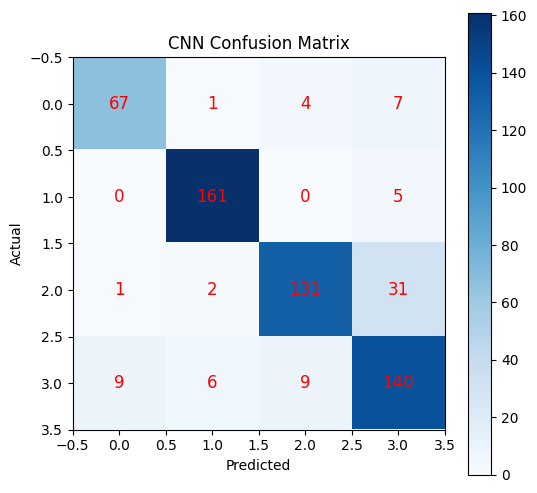

In [3]:
# ============================================================
# CNN MODEL
# ============================================================

cnn_model = Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

cnn_model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ============================================================
# TRAIN CNN
# ============================================================

history = cnn_model.fit(

    X_train,
    y_train_cat,

    epochs=10,

    batch_size=32,

    validation_data=(X_test, y_test_cat)
)

# ============================================================
# PREDICTIONS
# ============================================================

cnn_pred = cnn_model.predict(X_test)

cnn_pred = np.argmax(cnn_pred, axis=1)

# ============================================================
# METRICS
# ============================================================

cnn_acc = accuracy_score(y_test, cnn_pred)

cnn_f1 = f1_score(y_test, cnn_pred, average='weighted')

print(f"\nCNN Accuracy : {cnn_acc:.4f}")

print(f"CNN F1 Score : {cnn_f1:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_cnn = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm_cnn, cmap='Blues')

plt.title("CNN Confusion Matrix")

plt.colorbar()

for i in range(4):
    for j in range(4):

        plt.text(
            j,
            i,
            cm_cnn[i,j],
            ha='center',
            va='center',
            color='red',
            fontsize=12
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [4]:
# ============================================================
# LOAD VGG16
# ============================================================

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Feature extractor
feature_extractor = Model(

    inputs=base_model.input,

    outputs=base_model.output
)

# ============================================================
# PREPROCESS FOR VGG16
# ============================================================

X_train_vgg = preprocess_input(X_train * 255.0)

X_test_vgg = preprocess_input(X_test * 255.0)

# ============================================================
# EXTRACT FEATURES
# ============================================================

train_features = feature_extractor.predict(X_train_vgg)

test_features = feature_extractor.predict(X_test_vgg)

# ============================================================
# FLATTEN FEATURES
# ============================================================

train_features = train_features.reshape(
    train_features.shape[0],
    -1
)

test_features = test_features.reshape(
    test_features.shape[0],
    -1
)

print("Train Feature Shape :", train_features.shape)

print("Test Feature Shape :", test_features.shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step
Train Feature Shape : (2296, 25088)
Test Feature Shape : (574, 25088)



VGG16 + XGBoost Accuracy : 0.9199
VGG16 + XGBoost F1 Score : 0.9201


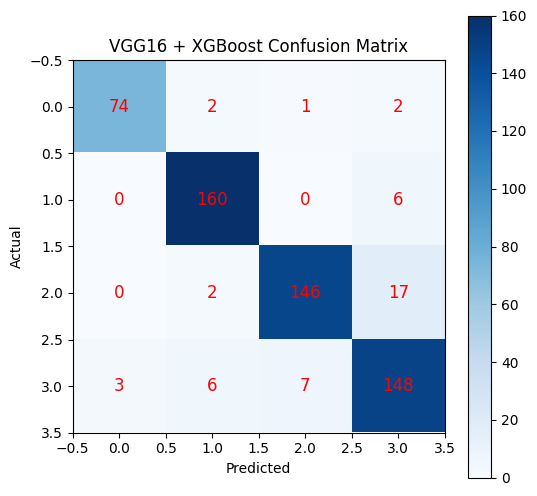

In [5]:
# ============================================================
# XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.1,

    objective='multi:softmax',

    num_class=4,

    eval_metric='mlogloss',

    random_state=42
)

# ============================================================
# TRAIN
# ============================================================

xgb_model.fit(train_features, y_train)

# ============================================================
# PREDICT
# ============================================================

xgb_pred = xgb_model.predict(test_features)

# ============================================================
# METRICS
# ============================================================

xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print(f"\nVGG16 + XGBoost Accuracy : {xgb_acc:.4f}")

print(f"VGG16 + XGBoost F1 Score : {xgb_f1:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm_xgb, cmap='Blues')

plt.title("VGG16 + XGBoost Confusion Matrix")

plt.colorbar()

for i in range(4):
    for j in range(4):

        plt.text(
            j,
            i,
            cm_xgb[i,j],
            ha='center',
            va='center',
            color='red',
            fontsize=12
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


VGG16 + SVM Accuracy : 0.9495
VGG16 + SVM F1 Score : 0.9496


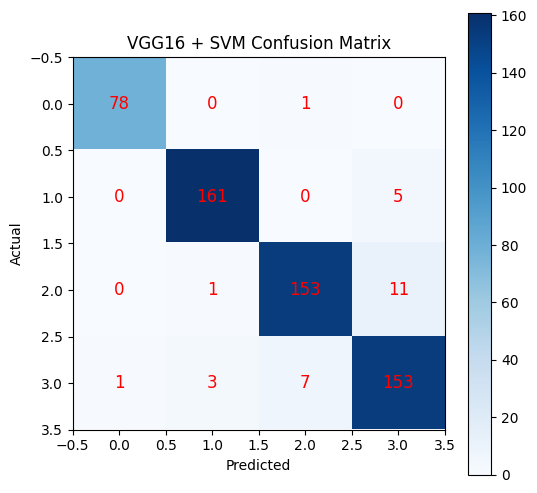

In [6]:
# ============================================================
# SVM MODEL
# ============================================================

svm_model = SVC(kernel='linear')

# ============================================================
# TRAIN
# ============================================================

svm_model.fit(train_features, y_train)

# ============================================================
# PREDICT
# ============================================================

svm_pred = svm_model.predict(test_features)

# ============================================================
# METRICS
# ============================================================

svm_acc = accuracy_score(y_test, svm_pred)

svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print(f"\nVGG16 + SVM Accuracy : {svm_acc:.4f}")

print(f"VGG16 + SVM F1 Score : {svm_f1:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm_svm, cmap='Blues')

plt.title("VGG16 + SVM Confusion Matrix")

plt.colorbar()

for i in range(4):
    for j in range(4):

        plt.text(
            j,
            i,
            cm_svm[i,j],
            ha='center',
            va='center',
            color='red',
            fontsize=12
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

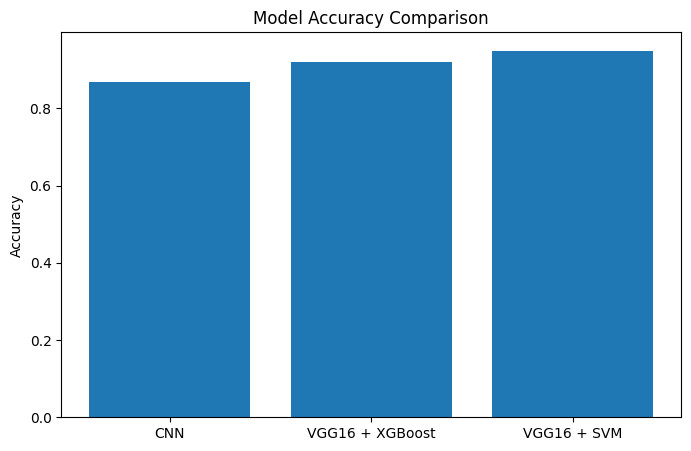

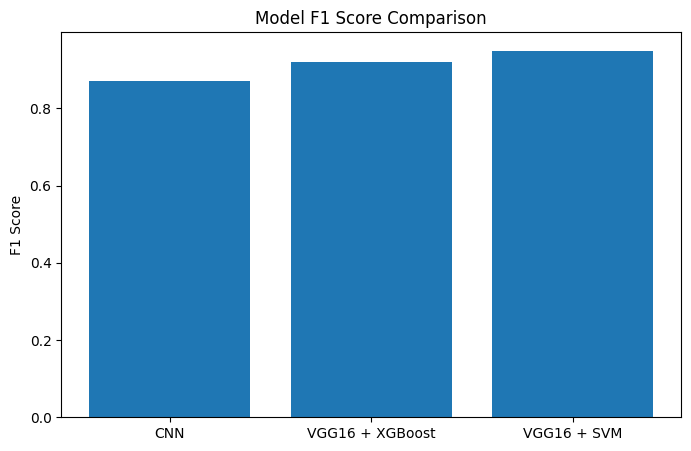


FINAL COMPARISON

CNN
Accuracy : 0.8693
F1 Score : 0.8697

VGG16 + XGBoost
Accuracy : 0.9199
F1 Score : 0.9201

VGG16 + SVM
Accuracy : 0.9495
F1 Score : 0.9496



In [7]:
# ============================================================
# FINAL COMPARISON
# ============================================================

models = [
    'CNN',
    'VGG16 + XGBoost',
    'VGG16 + SVM'
]

accuracies = [
    cnn_acc,
    xgb_acc,
    svm_acc
]

f1_scores = [
    cnn_f1,
    xgb_f1,
    svm_f1
]

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

# ============================================================
# F1 SCORE GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(models, f1_scores)

plt.ylabel("F1 Score")

plt.title("Model F1 Score Comparison")

plt.show()

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n================================================")
print("FINAL COMPARISON")
print("================================================\n")

for i in range(len(models)):

    print(f"{models[i]}")

    print(f"Accuracy : {accuracies[i]:.4f}")

    print(f"F1 Score : {f1_scores[i]:.4f}")

    print()